# 24BAD099 - Rithish A

   user_id  movie_id  rating   timestamp
0       52        29       1  1000000020
1       93        47       5  1000000010
2       15         4       4  1000000091
3       72        12       2  1000000004
4       61        45       1  1000000080
Similar Items to Movie 1:
 movie_id
25    0.361997
3     0.346417
7     0.306526
45    0.291920
22    0.291199
Name: 1, dtype: float64
Recommended Movies: [(32, 1.8286925998440255), (34, 1.6954731230075863), (6, 1.4895523602871457), (12, 1.421561381881067), (1, 1.3613568553022128)]
RMSE: 0.6708203932499369
Precision@5: 0.0


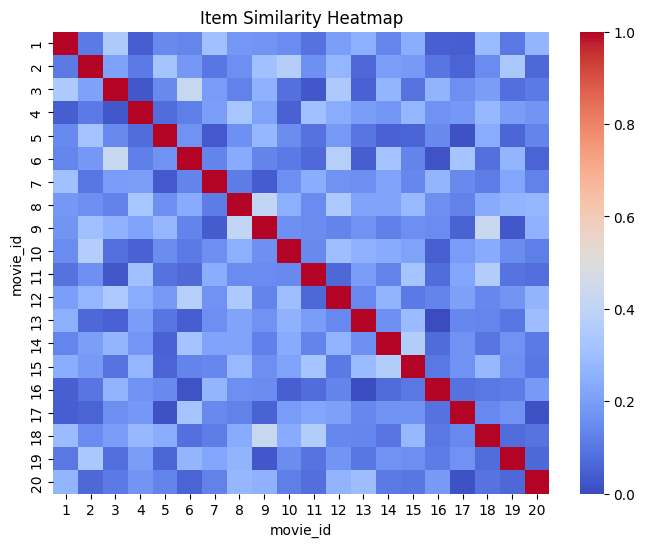

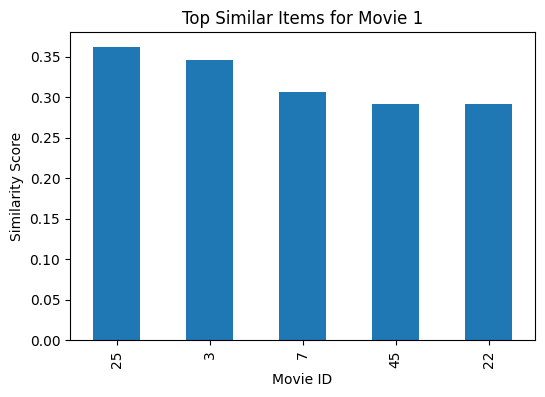

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

try:

    data = pd.read_csv("u.data", sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])

except FileNotFoundError:

    np.random.seed(42)

    n_users = 100

    n_movies = 50

    n_ratings = 1200

    data = pd.DataFrame(

        {

            "user_id": np.random.randint(1, n_users + 1, n_ratings),
            "movie_id": np.random.randint(1, n_movies + 1, n_ratings),
            "rating": np.random.randint(1, 6, n_ratings),
            "timestamp": np.random.randint(1000000000, 1000000100, n_ratings),

        }

    )


print(data.head())

item_user_matrix = data.pivot_table(index="movie_id", columns="user_id", values="rating", aggfunc="mean")
item_user_matrix_filled = item_user_matrix.fillna(0)
item_similarity = cosine_similarity(item_user_matrix_filled)
item_similarity_df = pd.DataFrame(item_similarity, index=item_user_matrix.index, columns=item_user_matrix.index)

def get_similar_items(movie_id, n=5):

    similar_items = item_similarity_df[movie_id].sort_values(ascending=False)

    return similar_items.iloc[1:n+1]

print("Similar Items to Movie 1:\n", get_similar_items(1))

def recommend_items(user_id, n=5):
    user_data = data[data["user_id"] == user_id]
    scores = {}

    for movie in user_data["movie_id"]:
        similar_items = get_similar_items(movie)

        for sim_movie, sim_score in similar_items.items():
            scores[sim_movie] = scores.get(sim_movie, 0) + sim_score

    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]

    return recommended

print("Recommended Movies:", recommend_items(1))

data["liked"] = data["rating"].apply(lambda x: 1 if x >= 4 else 0)

X = data[["user_id", "movie_id"]]
y = data["liked"]



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)



y_pred = dt.predict(X_test)



rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)



def precision_at_k(recommended, relevant, k=5):

    recommended_k = [x[0] for x in recommended[:k]]

    relevant_set = set(relevant)

    

    hit = len(set(recommended_k) & relevant_set)

    return hit / k



print("Precision@5:", precision_at_k(recommend_items(1), [10, 20, 30]))



plt.figure(figsize=(8, 6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap="coolwarm")
plt.title("Item Similarity Heatmap")
plt.show()



similar = get_similar_items(1)



plt.figure(figsize=(6, 4))
similar.plot(kind="bar")
plt.title("Top Similar Items for Movie 1")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()
